# Домашнее задание 2. Выпуклость и множители Лагранжа

**Выдано:** 23 сентября 2026 (обновлено 29 сентября). **Срок сдачи:** 7 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw02/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 2 ([конспект](../lectures/lecture02/lecture02.md), [демо](../lectures/lecture02/demo02.ipynb)) — операции, сохраняющие выпуклость (раздел 5), чек-лист выпуклой задачи (раздел 6), условие оптимальности (раздел 7); лекция 3 ([конспект](../lectures/lecture03/lecture03.md)) — баланс сил $\nabla f = \mu \nabla h$, касание $\nabla f = \lambda \nabla g$, функция Лагранжа и множитель как цена (разделы 4–8). Ничего сверх лекций не требуется. Ориентировочное время — 4–5 часов.

**Сложность** отмечена звёздочками: ★ — разминка, ★★ — стандартная задача, ★★★ — нужно подумать. Большая часть задания решается на бумаге; код нужен в задаче 3 и для коротких проверок.

| Задача | Баллы | О чём |
|--------|-------|-------|
| 1. Выпуклость | 3 | множества, критерий второго порядка, операции |
| 2. Три функции | 2 | функция Розенброка, log-sum-exp, наибольшее собственное число |
| 3. Выпуклая и невыпуклая подгонка | 2 | синус с неизвестной и известной частотой, мультистарт |
| 4. Множители Лагранжа | 3 | проекция на полупространство, собственные числа как касание, «водозаполнение» |
| Бонус | +1 | максимум энтропии и распределение Больцмана |

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(2026)   # для ваших собственных случайных проверок; данные задач генерируются отдельно

## Задача 1. Выпуклость (3 балла)

По 1 баллу за пункт. В каждом пункте нужен либо аргумент «почему выпукло» — определение, критерий первого/второго порядка или операция из раздела 5 конспекта, — либо контрпример: две точки и вылезающий наружу отрезок, хорда под графиком или точка, где гессиан не полуопределён. Численная проверка приветствуется, но доказательством не считается (демо, часть a).

**(а) Множества** ★. Выпуклы ли:

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;
2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;
3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$?

**(б) Критерий второго порядка** ★.

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.
2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

**(в) Операции** ★★. Докажите выпуклость или объясните, почему правила раздела 5 не применимы, и приведите контрпример:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$.

Какие из трёх функций гладкие?

**(а)**

**Ответ:** 

1. **Множество выпуклое**  
Это надграфик $f(x_2)=x_1^2$  
$x_1^2$ является выпуклой, поскольку гессиан положительный (и равен 2)  
надграфик выпуклой функции - выпуклое множество

2. **Множество выпуклое**  
Норма $\Vert x \Vert_2$ является выпуклой (по неравенству треугольника)  
$Ax + b$ является аффинным отображением, следовательно их композиция тоже выпукла  
Для любого $с$ и выпуклой функции $f(x)$ множество $\{x : f(x) \le c\}$ выпукло

3. **Множество невыпуклое**  
Возьмём точки $x_1 = (0; 1)$ и $x_2 = (0; -1)$
Для них выполняется условие множества, но для отрезка, построенного по ним - нет  
(например, точка c = $(0; 0)$, $\Vert c \Vert_2 = 0$)

**(б)**

**Ответ:** 

1. Функция выпукла при значениях $-2 \le a \le 2$, при значениях $-2 < a < 2$ функция строго выпукла  
$H = \begin{pmatrix} 2 & a \\ a & 2 \end{pmatrix}$, при поиске собственных значений получили $(2-a+\lambda)(2+a-\lambda)=0$  
Получили систему, где $\lambda_1=2-a$ и $\lambda_2=2+a$. Сравнили с нулём и получили ответ

2. Выполняя те же действия для функции $g(x)$ получили собственные значения $\lambda_1=-2x_1x_2$ и $\lambda_2=6x_1x_2$ или $\lambda_1=2x_1x_2$ и $\lambda_2=-6x_1x_2$  
В пространстве $\mathbb{R}^2$ функция не является выпуклой. При значениях $x_1=1$ и $x_2=1$ одно из собственных значений гарантированно отрицательно.

In [18]:
for a in [-2.1, -2.0, 0.0, 1.9, 2.0, 2.1]:
    H = np.array([[2.0, a],[a, 2.0]])
    
    eigvals = np.linalg.eigvalsh(H)
    min_eig = eigvals[0]
    
    if min_eig > 0:
        status = "Строго выпукла"
    elif min_eig >= 0:
        status = "Выпукла"
    else:
        status = "Не выпукла"
    eigvals_str = f"[{eigvals[0]:5.2f}, {eigvals[1]:5.2f}]"
    print(f"a = {a:4.1f} | Собств. значения: {eigvals_str} | Мин: {min_eig:4.1f} | {status}")

a = -2.1 | Собств. значения: [-0.10,  4.10] | Мин: -0.1 | Не выпукла
a = -2.0 | Собств. значения: [ 0.00,  4.00] | Мин:  0.0 | Выпукла
a =  0.0 | Собств. значения: [ 2.00,  2.00] | Мин:  2.0 | Строго выпукла
a =  1.9 | Собств. значения: [ 0.10,  3.90] | Мин:  0.1 | Строго выпукла
a =  2.0 | Собств. значения: [ 0.00,  4.00] | Мин:  0.0 | Выпукла
a =  2.1 | Собств. значения: [-0.10,  4.10] | Мин: -0.1 | Не выпукла


**(в)**

**Ответ:** 

1. Функция выпукла  
В задании 1а2 уже показано, что  $\Vert Ax - b\Vert_2$ является выпуклой функцией  
Любая норма является выпуклой (и $\Vert x \Vert_\infty$ соответственно)  
Неотрицательная взвешенная сумма выпуклых функций - выпукла

2. Функция выпукла  
Рассмотрим функцию $g_i(x) = \big(a_i^\top x - b_i\big)^2$ как композицию (четвёртый критерий) $\phi_1(x) = a_i^\top x - b_i$ и $\phi_2(x) = x^2$  
$\phi_1(x)$ является афинным преобразованием и выпукло, $\phi_2(x)$ выпукла (по гессиану), но условие неприменимо, поскольку не является монотонной  
Гессиан функции $g_i(x)$ равен $H = 2a_ia_i^\top$. Для любого вектора $v$ выполняется условие $v^\top \big( a_ia_i^\top \big) v = \big ( a_i^\top v \big )^2 \ge 0$  
(значит гессиан положительно полуопределён и функция выпуклая)  
Применим второй критерий. Поскольку $g_i$ является выпуклой функцией, то поточечный максимум также является выпуклым

3. Функция невыпукла  
Воспользуемся четвёртым критерием. $g(x) = e^x$, $f(x) = - \Vert x \Vert_2^2$  
Функция $g(x)$ является монотонной и выпуклой (по гессиану), функция $f(x)$ не является монотонной (гессиан всегда отрицательный)  
Поэтому воспользоваться критериями нельзя. Контрпример: возьмём точки $x_1=(0;1)$ и $x_2=(0;-1)$, тогда $f(x_1)=e^{-1}$, $f(x_2)=e^{-1}$  
Возьмём точку на отрезке $x_1x_2$, $c=(0;0)$, тогда $f(c)=1$  
Для таких точек не выполняется условие выпуклости функции: $f(c) \le 0,5f(x_1)+0,5f(x_2)$

## Задача 2. Три функции (2 балла)

**(а) Функция Розенброка** ★ (0.5 балла). $f(x) = (1 - x_1)^2 + 100\,(x_2 - x_1^2)^2$ — «банановая долина», на которой в части II будем испытывать все методы.

1. Докажите, что $f$ не выпукла: предъявите хорду, лежащую под графиком, или точку, где гессиан не полуопределён.
2. Найдите множество точек, где $\nabla^2 f(x) \succeq 0$. Как оно расположено относительно дна долины $x_2 = x_1^2$?
3. Найдите все стационарные точки $f$. Почему у этой невыпуклой функции единственный локальный минимум оказался глобальным и не противоречит ли это лекции 2?

**(б) Гладкий максимум: log-sum-exp** ★★ (0.75 балла). $\operatorname{lse}(x) = \log \sum_{i=1}^n e^{x_i}$, $x \in \mathbb{R}^n$.

1. Докажите, что $\max_i x_i \le \operatorname{lse}(x) \le \max_i x_i + \log n$.
2. Для $t > 0$ положим $\operatorname{lse}_t(x) = \tfrac1t \operatorname{lse}(t x)$. Покажите, что $\operatorname{lse}_t(x) \to \max_i x_i$ при $t \to \infty$, и оцените погрешность.
3. Вычислите градиент и гессиан $\operatorname{lse}$ и докажите, что $\operatorname{lse}$ выпукла. Подсказка: обозначьте $p_i = e^{x_i} / \sum_j e^{x_j}$ и сведите $v^\top \nabla^2 \operatorname{lse}(x)\, v \ge 0$ к неравенству Коши–Буняковского (или к неотрицательности дисперсии). Строго ли она выпукла?
4. Проверьте оценку из пункта 2 численно для случайного $x \in \mathbb{R}^{10}$ с координатами порядка $10$ и $t = 1, 10, 100$. Посчитайте $\operatorname{lse}$ «в лоб», `np.log(np.sum(np.exp(t * x))) / t`, и через `scipy.special.logsumexp`. Что ломается при $t = 100$ и как `logsumexp` этого избегает?

Зачем это нужно: $\max$ выпукл, но негладок, а $\operatorname{lse}_t$ — его гладкая выпуклая замена сверху. Так, например, сглаживают чебышёвскую подгонку из бонуса ДЗ 1.

**(в) Наибольшее собственное число** ★★★ (0.75 балла). $\mathbb{S}^n$ — пространство симметричных матриц $n \times n$, у $X \in \mathbb{S}^n$ собственные числа $\lambda_1(X) \ge \dots \ge \lambda_n(X)$.

1. Докажите, что $\lambda_1(X) = \max_{\Vert v\Vert = 1} v^\top X v$, и выведите отсюда, что $\lambda_1$ — выпуклая функция на $\mathbb{S}^n$, а $\lambda_n$ — вогнутая. Подсказка: при фиксированном $v$ отображение $X \mapsto v^\top X v$ линейно по $X$.
2. Выпукло ли множество положительно полуопределённых матриц $\{X \in \mathbb{S}^n : X \succeq 0\}$? А множество $\{X : \lambda_1(X) \le 1\}$?
3. Выпукла или вогнута на $\mathbb{S}^3$ функция $\lambda_2(X)$ — второе по величине собственное число? Достаточно диагональных матриц.

**(а)**

**Ответ:**

1. Рассчитаем гессиан. $H = \begin{pmatrix} 2 - 400x_2 + 1200x_1^2 & -400x_1 \\ -400x_1 & 200 \end{pmatrix}$  
Собственные значения посчитаны в коде  
Чтобы гессиан был положительно полуопределён, его определитель и путь должны быть неотрицательными: $det(H) \ge 0$, $tr(H) \ge 0$  
Получили решения относительно $x_2$. Найдём пересечение полуинтервалов. Для этого сравним значения справа  
$3x_1^2 + \frac{101}{200} - x_1^2 - \frac{1}{200} = 2x_1^2 + 0,5 \ge 0$ для любых значений $x_1$  
Из этого следует, что при выполнении неравенства, вытекающего из условия детерминанта, выполняется и условие для пути  
Гессиан не положительно полуопределён (а соответственно функция не выпукла) в точке $\bold x = (0; 1)$

2. $\{ \bold x \in \mathbb{R}^2: x_2 \le x_1^2 + \frac{1}{200} \}$. В этом множестве лежит дно долины, то есть функция Розенброка выпукла только в узкой окрестности дна долины

3. $\begin{cases} \frac{\partial f}{\partial x_1} = -2(1-x_1)-400x_1(x_2-x_1^2) = 0 \\ \frac{\partial f}{\partial x_2} = 200(x_2-x_1^2) = 0 \end{cases}$  
Решая систему уравнений, получаем точку $\bold x^* = (1; 1)$, которая является стационарной  
Поскольку функция является положительной взвешенной суммой квадратов, минимальное значение равно нулю  
(как раз в точке $\bold x^*$ достигается это значение) и оно является глобальным минимумом  
Данный факт не является противоречием второй лекции, поскольку выпуклость задачи является достаточным условием для единственного глобального минимума


In [10]:
import sympy as sp

x1, x2 = sp.symbols('x1 x2', real=True)

f = (1 - x1)**2 + 100 * (x2 - x1**2)**2
H = sp.hessian(f, (x1, x2))

print("Определитель гессиана:")
det_H = sp.simplify(H.det())
sp.pprint(det_H)

print("\nСлед гессиана:")
tr_H = sp.simplify(H.trace())
sp.pprint(tr_H)

print("\nУсловие det(H) >= 0:")
det_ineq = sp.solve(det_H >= 0, x2)
sp.pprint(det_ineq)

print("\nУсловие trace(H) >= 0:")
trace_ineq = sp.solve(tr_H >= 0, x2)
sp.pprint(trace_ineq)

Определитель гессиана:
        2                 
80000⋅x₁  - 80000⋅x₂ + 400

След гессиана:
       2               
1200⋅x₁  - 400⋅x₂ + 202

Условие det(H) >= 0:
       2    1 
x₂ ≤ x₁  + ───
           200

Условие trace(H) >= 0:
         2   101
x₂ ≤ 3⋅x₁  + ───
             200


**(б)**

**Ответ:** 

1. $\operatorname{lse}(x) = \log \sum_{i=1}^n e^{x_i} = \log (e^{x_1} + e^{x_2} + ... + e^{x_n}) = \log e^{x_k}(e^{x_1 - x_k} + e^{x_2 - x_k} + ... + 1 + ... + e^{x_n - x_k}) = $  
$x_k + \log (e^{x_1 - x_k} + e^{x_2 - x_k} + ... + 1 + ... + e^{x_n - x_k})$, где $x_k = \max_i x_i$  
$e^{x_i-x_k}$ является положительным значением меньше 1 для любого $x_i$  
Рассмотрим выражение $\log (e^{x_1 - x_k} + e^{x_2 - x_k} + ... + 1 + ... + e^{x_n - x_k})$  
Оно ограничено слево нулём в случае, когда значения $x_i$ (кроме $x_k$) стремятся к $-\infty$  
Справа выражение ограничено $\log n$ в случае, когда все значения $x_i$ одинаковые и под логарифмом каждое слагаемое $e^{x_i-x_k} \le e^0 = 1$ и сумма $n$ таких слагаемых $\le n$ 
Следовательно, $\max_i x_i \le \operatorname{lse}(x) \le \max_i x_i + \log n$ (ч.т.д)

2. Рассмотрим неравенство из первого пункта для нашего условия  
$\max_i (tx_i) \le \log \sum_{i=1}^n e^{tx_i} \le \max_i (tx_i) + \log n$  
Поделим всё выражение на $t$  
$\max_i (x_i) \le \operatorname{lse_t}(x) \le \max_i (x_i) + \frac {\log n}{t}$  
При $t$ стремящейся к $\infty$ правая часть стремится к $\max_i (x_i)$. Следовательно по теореме о зажатой переменной $\operatorname{lse_t}(x)$ стремится к $\max_i (x_i)$  
Погрешность:  
$0 \le \operatorname{lse_t}(x) - \max_i (x_i) \le \frac {\log n}{t}$

3. Вычислим градиент. Частная производная по $x_k$:  
$\frac{\partial}{\partial x_k} \log \sum_{i=1}^n e^{x_i} = \frac {e^x_k}{\sum_{i=1}^n e^{x_i}} = p_k$  
Градиент $\nabla\operatorname{lse}(x) = p = \big ( p_1, p_2, ..., p_n \big )^\top$  
Вычислим гессиан. Вторые частные производные для диагональных элементов:  
$\frac{\partial^2}{\partial^2 x_k} \operatorname{lse}(x) = p_k - p_k^2$  
Вторые частные производные для недиагональных элементов:  
$\frac{\partial^2}{ \partial x_k \partial x_j} \operatorname{lse}(x) = - p_k p_j$  
$H = diag(p) - pp^\top$  
Для доказательства выпуклости функции, рассмотрим выражение:  
$v^\top H v = v^\top (diag(p) - pp^\top)x$  
Раскроем выражение:  
$v^\top H v = \sum_{i=1}^n p_i v_i^2 - (\sum_{i=1}^n p_i v_i)^2$  
Поскольку значения $p_i$ лежат в диапазоне $[0; 1]$, а их сумма равна 1, то раскрытое выражение является дисперсией случайной величины и неотрицательным значением  
Это означает, что матрица Гесса положительна полуопределена и функция выпукла  
Гессиан не является положительно определённым, поскольку выражение $v^\top H v = 0$ не только при значениях $v = 0$, но и при $v = c * \bold 1$

4. Код представлен ниже  
scipy.special.logsumexp использует для вычисления логарифма суммы следующее выражение:  
$\log \sum_{i=1}^n e^{x_i} = \log \sum_{i=1}^n e^{x_i-M+M} = M + \log \sum_{i=1}^n e^{x_i-M}$, где $M = \max_i x_i$  
Благодаря этому все экспоненты $\le 1$ и не происходит переполнения

In [16]:
import numpy as np
from scipy.special import logsumexp

x = np.random.randn(10) * 10

print(f"x = {x}")
print(f"max(x) = {np.max(x):.6f}")
print()

for t in [1, 10, 100]:
    lse_naive = np.log(np.sum(np.exp(t * x))) / t
    lse_scipy = logsumexp(t * x) / t
    
    error = lse_scipy - np.max(x)
    error_bound = np.log(10) / t 
    
    print(f"t = {t:3d}:")
    print(f"  lse (naive)  = {lse_naive:.10f}")
    print(f"  lse (scipy)  = {lse_scipy:.10f}")
    print(f"  Погрешность  = {error:.2e}")
    print(f"  Оценка log(n)/t = {error_bound:.2f}")
    print()

x = [  2.64259684  -4.74028407  -1.65637662  26.60982433  -7.61402912
  -0.789874     5.85136844  -7.65153701  17.80929556 -11.29570776]
max(x) = 26.609824

t =   1:
  lse (naive)  = 26.6099749719
  lse (scipy)  = 26.6099749719
  Погрешность  = 1.51e-04
  Оценка log(n)/t = 2.30

t =  10:
  lse (naive)  = 26.6098243288
  lse (scipy)  = 26.6098243288
  Погрешность  = -3.55e-15
  Оценка log(n)/t = 0.23

t = 100:
  lse (naive)  = inf
  lse (scipy)  = 26.6098243288
  Погрешность  = 0.00e+00
  Оценка log(n)/t = 0.02



C:\Users\Женя\AppData\Local\Temp\ipykernel_28500\3830209147.py:11: RuntimeWarning: overflow encountered in exp
  lse_naive = np.log(np.sum(np.exp(t * x))) / t


**(в)**

**Ответ:** 

1. Поскольку матрицы $X$ симметричная, имеется ортонормированный базис из собственных векторов, каждому из которых соответствует собственное значение  
Вектор $v$ с нормой равной единице можно разложить по базису собственных векторов: $\sum_{i=1}^n c_i u_i$, где  $\sum_{i=1}^n c_i = 1$  
Подставим разложение в $v^\top X v$:  
$\big ( \sum_{i=1}^n c_i u_i \big ) ^\top X \sum_{i=1}^n c_i u_i = \sum_{i=1}^n \lambda_i c_i^2$ (из связи собственных векторов и значений)  
Оценим сверху:  
$\sum_{i=1}^n \lambda_i c_i^2 \le \sum_{i=1}^n \lambda_1 c_i^2 \le \lambda_1 \sum_{i=1}^n c_i^2 \le \lambda_1$  
$\lambda_1$ достигается, есть вектор $v$ равен собственному вектору $u$ и тогда:  
$\lambda_1(X) = \max_{\Vert v\Vert = 1} v^\top X v$  
Докажем, что $\lambda_1$ является выпуклой функцией:  
Фиксируем вектор $v$ и рассматриваем функцию $f_v(X) = v^\top X v$  
Функция является афинным преобразованием, а следовательно выпуклой  
Рассмотрим $\lambda_1(X) = \max_{\Vert v \Vert_2} f_v(X)$. Здесь собственное значение вычисляется как поточечный максимум (критерий 3) от выпуклых функций, значит $\lambda_1$ - выпуклая функция  
Докажем, что $\lambda_n(X)$ является вогнутой функцией  
Рассмотрим матрицу $-X$. Её собственные векторы совпадают с собственными векторами $X$, а собственные значения меняют знак  
Наибольшее собственное значение матрицы $-X$ является $-\lambda_n(X)$  
По форумуле из первого шага $\lambda_1(-X) = -\lambda_n(X)$ или $\lambda_n(X) = -\lambda_1(-X)$  
Отображение из $X$ в $-X$ является аффинным. Композиция выпуклых функций - выпукла (значит, $\lambda_1(-X)$ выпукла)  
Если $f(x)$ является выпуклой, то $-f(x)$ - вогнутая, что и видно в нашем случае для $\lambda_n(X) $\

2. Чтобы множество положительно полуопределённых матриц $X$ было выпукло, надо, чтобы все её собственные значения были неотрицательными  
Поскольку собственные значения симметричных матриц идут в порядке убывания, можно рассматривать только $\lambda_n(X) \ge 0$  
Из следствия подуровневых множеств, ограничение вогнутой функции задаёт выпуклое множество  
В нашем случае $\lambda_n(X)$ является вогнутой (из пункта 1), следовательно такое множество матриц $X$ является выпуклым  
Рассмотрит множество $\{ X: \lambda_1(X) \le 1\}$  
Оно является выпуклым, поскольку функция $\lambda_1(X)$ является выпуклой и для любого $c$ (в нашем случае 1) множество $\{ X : \lambda_1(X) <= 1 \}$ выпукло

3. Рассмотрим диагональную матрицу $X = diag(x_1; x_2; x_3)$  
В таком случае собственные числа равны диагональным элементам матрицы  
Поскольку собственные значения в порядке убывания, $\lambda_2 = median(x_1; x_2; x_3)$  
Опровергнем выпуклость $\lambda_2$:  
Возьмём матрицы $X = diag(1; 0; 0)$ и $Y = diag(0; 0; 1)$, тогда $Z = 0,5X + 0,5Y = diag(0,5; 0; 0,5) $ $\lambda_2(Z)=0,5 > 0,5*0 + 0,5*0 = 0$   
Опровергнем вогнутость $\lambda_2$:  
Возьмём матрицы $X = diag(1; 1; 0)$ и $Y = diag(0; 1; 1)$, тогда $Z = 0,5X + 0,5Y = diag(0,5; 1; 0,5) $ $\lambda_2(Z)=0,5 > 0,5*1 + 0,5*1 = 1$   

## Задача 3. Выпуклая и невыпуклая подгонка ★★ (2 балла)

Пункт 1 — 0.5 балла, пункты 2 и 3 — по 0.75.

Ниже сгенерированы измерения $y_i = 2\sin(3t_i + 0.7) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, 0.2^2)$, $i = 1, \dots, 60$. Один и тот же сигнал описываем двумя моделями:

- **A** (задача 1(г) ДЗ 1): $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ — амплитуда, частота и фаза неизвестны;
- **B** (частота известна, $\omega = 3$): $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$.

Цель в обоих случаях — сумма квадратов невязок $f(x) = \tfrac12\sum_i \big(\varphi(t_i; x) - y_i\big)^2$.

1. Какого класса каждая задача и выпукла ли она? Для B — докажите; для A — объясните, почему нет (подсказка: что происходит с $f$ при $x_3 \to x_3 + 2\pi$ и при $(x_1, x_3) \to (-x_1, x_3 + \pi)$?).
2. Запустите `minimize(..., method="BFGS")` для обеих моделей из 20 одинаковых случайных стартов `starts` (для B берите первые две координаты старта). Выведите итоговые значения $f$ по стартам и долю стартов, пришедших к наименьшему найденному значению; нарисуйте данные и подогнанные кривые для обеих моделей.
3. Объясните результат через главную теорему лекции. Как из решения B получить амплитуду и фазу для модели A? Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?

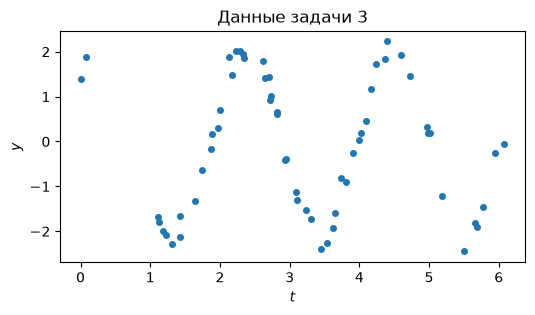

In [17]:
data_rng = np.random.default_rng(2026)          # отдельный генератор: данные не зависят от вашего кода выше
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))         # 20 общих стартов для обеих моделей

plt.figure(figsize=(6, 3))
plt.plot(t, y, "o", ms=4)
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 3")
plt.show()

**Класс и выпуклость (пункт 1)**

**Ответ:**

Модель B (выпуклая, QP):  
Запишем модель в матричном виде, где $A$ - матрица размером 60 на 2, первая колонка $\sin(3t_i)$, а вторая - $\cos(3t_i)$  
Тогда $\phi_B = \frac{1}{2} \Vert Ax-y \Vert_2^2 = \frac{1}{2} x^\top \big ( A^\top A \big ) x - \big ( A^\top y \big ) ^ \top x + \frac{1}{2}y^\top y$  
Гессиан равен $H = A^\top A$. Такая матрица положительно полуопределена (доказывается через $v^\top \big ( A^\top A) v$), следовательно функция выпукла

Модель A (невыпуклая, NLP):  
Функция даёт множество глобальных минимумов, причём невыпуклое множество (то есть не отрезок, а дискретные точки). Это значит, что функция невыпукла

**Мультистарт (пункт 2)**

Модель A: min f = 1.13927, доля успешных стартов = 55%
Модель B: min f = 1.14076, доля успешных стартов = 100%


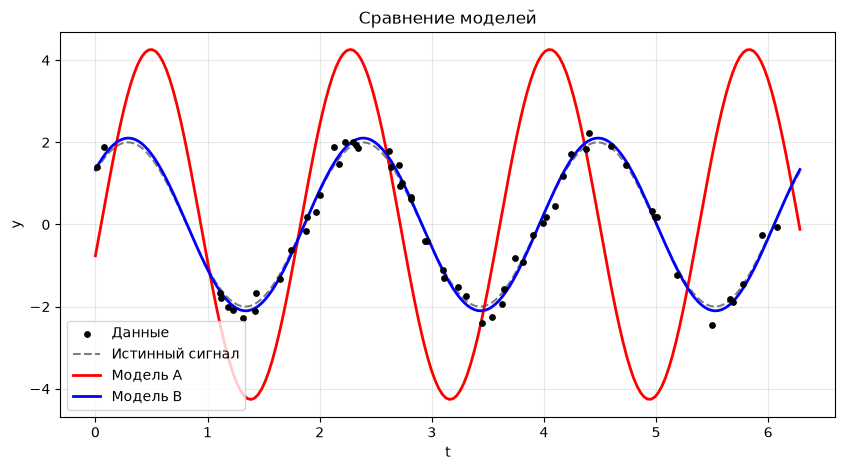

In [22]:
def model_A(x, t):
    return x[0] * np.sin(x[1] * t + x[2])

def model_B(x, t):
    return x[0] * np.sin(omega * t) + x[1] * np.cos(omega * t)

def objective_A(x):
    return 0.5 * np.sum((model_A(x, t) - y)**2)

def objective_B(x):
    return 0.5 * np.sum((model_B(x, t) - y)**2)

results_A = []
results_B = []

for i in range(20):
    start_A = starts[i]
    start_B = starts[i, :2]
    
    res_A = minimize(objective_A, start_A, method="BFGS")
    res_B = minimize(objective_B, start_B, method="BFGS")
    
    results_A.append(res_A.fun)
    results_B.append(res_B.fun)

min_f_A = np.min(results_A)
min_f_B = np.min(results_B)

tol = 1e-5
success_rate_A = np.sum(np.abs(np.array(results_A) - min_f_A) < tol) / 20
success_rate_B = np.sum(np.abs(np.array(results_B) - min_f_B) < tol) / 20

print(f"Модель A: min f = {min_f_A:.5f}, доля успешных стартов = {success_rate_A:.0%}")
print(f"Модель B: min f = {min_f_B:.5f}, доля успешных стартов = {success_rate_B:.0%}")

best_x_A = starts[np.argmin(results_A)]
idx_B = np.argmin(results_B)
best_x_B = starts[idx_B, :2]
res_B_best = minimize(objective_B, best_x_B, method="BFGS")
best_x_B = res_B_best.x

t_smooth = np.linspace(0, 2 * np.pi, 200)

plt.figure(figsize=(10, 5))
plt.scatter(t, y, color='black', s=15, label='Данные', zorder=5)

plt.plot(t_smooth, 2.0 * np.sin(3.0 * t_smooth + 0.7), 'k--', alpha=0.5, label='Истинный сигнал')

plt.plot(t_smooth, model_A(best_x_A, t_smooth), 'r-', linewidth=2, label=f'Модель A')
plt.plot(t_smooth, model_B(best_x_B, t_smooth), 'b-', linewidth=2, label=f'Модель B')

plt.xlabel("t")
plt.ylabel("y")
plt.title("Сравнение моделей")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Объяснение (пункт 3)**

**Ответ:**  

1. Модель A является невыпуклой, из-за чего метод BFGS сходится к локальному минимуму (зависящему от начальной точки).  
Модель B является выпуклой и согласно главной теореме, если задача выпукла, то любой её локальный минимум является глобальным

2. Для этого необходимо воспользоваться тождеством: $x_1 \sin(wt) + x_2 \cos(wt) = R \sin(wt + \phi)$, где $R = \sqrt{x_1^2 + x_2^2}, \phi = \arctan(x2, x1)$  

3. В модели A три параметра (амплитуда, фаза и частота), а в модели B только два параметра.  
Из-за этого модель A способна лучше подстроиться под данные.  
Модель B и так знает истинную частоту искомой функции, а модель A подстраивает параметр под обучаемый набор данных.  
Но поскольку данные с шумом, модель подстраивается под него (переобучение)

## Задача 4. Множители Лагранжа (3 балла)

По 1 баллу за пункт. Обозначения — как в лекции 3: задача $\min f(x)$ при $g(x) = 0$, $h(x) \ge 0$; $L = f - \lambda^\top g - \mu^\top h$; система ККТ — $\nabla_x L = 0$, допустимость, $\mu \ge 0$, $\mu_i h_i = 0$.

**(а) Проекция на полупространство: две дороги к одному ответу** ★. Пусть $\Omega = \{x \in \mathbb{R}^n : a^\top x \le b\}$, $a \ne 0$, и точка $p$ лежит вне $\Omega$: $a^\top p > b$. Задача проекции — $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$.

1. **Через условие лекции 2.** Из $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0\ \ \forall y \in \Omega$ выведите
$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$
Подсказки: (i) почему $x^\ast$ не может лежать строго внутри $\Omega$; (ii) для любого $v$ с $a^\top v = 0$ точки $y = x^\ast \pm v$ допустимы — что даёт условие для них; (iii) коэффициент при $a$ найдите из $a^\top x^\ast = b$; (iv) убедитесь, что условие выполнено для всех $y \in \Omega$.
2. **Через баланс сил лекции 3.** Запишите $h(x) = b - a^\top x \ge 0$ и условие $\nabla f = \mu \nabla h$. Получите ту же формулу и значение $\mu^\ast$; почему $\mu^\ast \ge 0$ ровно тогда, когда $p \notin \Omega$? Как $\mu^\ast$ связано с расстоянием от $p$ до $\Omega$?
3. **Цена.** Найдите $f^\ast(b)$ и проверьте, что $df^\ast / db = -\mu^\ast$. Объясните знак.

**(б) Собственные числа как касание** ★★. $A \in \mathbb{S}^n$, задача $\min$ (или $\max$) $x^\top A x$ при $\Vert x\Vert^2 = 1$.

1. Запишите условие касания $\nabla f = \lambda \nabla g$ и покажите, что его решения — ровно единичные собственные векторы $A$, а множитель $\lambda$ равен собственному числу и значению $f$ в этой точке. Выведите, что $\min = \lambda_n(A)$, $\max = \lambda_1(A)$ (почему минимум и максимум вообще существуют?). Сравните с задачей 2(в).
2. Для $A = \operatorname{diag}(1, 2, 3)$ перечислите все точки, где выполнено условие касания. Покажите, что $\pm e_2$ — ни минимум, ни максимум: сдвиньтесь по сфере в сторону $e_1$ и в сторону $e_3$. Какой вывод о системе ККТ для невыпуклых задач? Выпукла ли эта задача?
3. Замените ограничение на $\Vert x\Vert^2 = r$, $r > 0$. Найдите $f^\ast_{\min}(r)$ и $df^\ast_{\min}/dr$ и сравните с $\lambda$.

**(в) Водозаполнение** ★★★. Мощность $P > 0$ распределяется между $n$ каналами связи с уровнями шума $\alpha_i > 0$; пропускная способность канала с мощностью $x_i$ равна $\log(\alpha_i + x_i)$ (с точностью до константы). Задача:
$$\max_x \sum_{i=1}^n \log(\alpha_i + x_i) \quad\text{при}\quad \sum_i x_i = P,\ \ x_i \ge 0 .$$
1. Приведите задачу к виду $\min f$ и докажите, что она выпукла.
2. Выпишите систему ККТ и выведите решение
$$x_i^\ast = \max(0,\ w - \alpha_i),$$
где «уровень воды» $w$ определяется уравнением $\sum_i \max(0, w - \alpha_i) = P$. Почему у этого уравнения ровно одно решение? Объясните название: на что похожа картинка «дно $\alpha_i$ + налитая вода $x_i$»? Какие каналы не получают ничего и какой у них множитель?
3. Для $\alpha = (0.4,\ 0.8,\ 1.2,\ 2.0,\ 3.0)$ и $P = 2$ найдите $w$, $x^\ast$, $\lambda^\ast$ и $\mu^\ast$ **руками**, затем проверьте кодом (`minimize` с `method="SLSQP"` или бисекция по $w$) и нарисуйте картинку «сосудов».
4. На сколько вырастет суммарная пропускная способность, если добавить немного мощности? Ответьте через множитель и проверьте конечной разностью.

In [4]:
alpha = np.array([0.4, 0.8, 1.2, 2.0, 3.0])   # уровни шума в каналах, задача 4(в)
P = 2.0                                        # суммарная мощность

**(а)**

**Ответ:**

1. По лекции для выпуклой задачи точка $x^*$ является решением тогда и только тогда, когда $\nabla f(x^*)^\top (y - x^*) \ge 0$ для всех допустимых $y$  
Для задачи проекции $f(x)=\frac{1}{2} \Vert x - p \Vert^2$, $\nabla f(x) = x - p$  
Условие принимает вид $(x^* - p)^\top (y - x^*) \ge 0$ для $y \in \Omega$
Если бы $x^*$ лежало бы строго во множестве $\Omega$, то допустимые направления $y-x^*$ заполнили бы всё пространство $\mathbb{R}^n$  
Тогда неравенство вида $(x^* - p)^\top v \ge 0$ для всех $v \in \mathbb{R}^n$ возможно только при $x^* = p$, но по условию $p$ не принадлежит множеству $\Omega$  
Значит $x^*$ лежит на границе ($a^\top x^* = b$)  
Если взять вектор $v$ ортогональный вектору $a$ ($a^\top v = 0$), то тогда точки $y = x^* \pm v$ допустимы ($a^\top (x^* \pm v) = a^\top x^* = b \le b$)  
Подставим $y=x^* + v: (x^* - p)^\top v \ge 0$. Подставим $y=x^* - v: (x^* - p)^\top (-v) \ge 0$, то есть $(x^* - p)^\top v \le 0$  
Оба условия выполняются при $(x^*-p)^\top v = 0$, то есть вектор $x^*-p$ коллинеарен $a$ и $x^*-p = \alpha a$. $x^* = p +\alpha a$  
Подставим $x^*$ в $a^\top x^* = b$. $a^\top (p + \alpha a) = b$. $a^\top p + \alpha \Vert a \Vert^2 = b$. $\alpha = \frac{b - a^\top p}{\Vert a \Vert^2}$  
Подставляем $\alpha$ обратно (но меняем знак, поскольку это не влияет на коллиниарность): $x^* = p - \frac{a^\top p - b}{\Vert a \Vert^2}$  
Проверим, что условие выполняется для всех $y \in \Omega$. Подставляем $x^* - p = \alpha a$: $(x^* - p)^\top (y-x^*) = (\alpha a)^\top (y-x^*)=\alpha (a^\top y - a^\top x^*) = \alpha (a^\top y - b)$  
Поскольку все $y \in \Omega$, то $a^\top y - b \le 0$. Поскольку $p \notin \Omega$, то $a^\top p \gt b$, значит $\alpha \gt 0$ и произведение их произведение $\ge 0$ (условие выполнено)

2. Воспользуемся условием для одной стенки $\nabla f(x^*) = \mu \nabla h (x^*), \mu \ge 0, h(x) = b - a^\top x \ge 0$  
$\nabla f(x) = x - p, \nabla h (x) = -a$  
$x^* - p = \mu (-a), x^* = p - \mu a$  
По условию комплементарной нежёсткости: $\mu h(x^*) = 0$. Если $\mu=0$, то $x^* = p$, но $p \notin \Omega$, значит $\mu \gt 0$  
Из $h(x^*)=0$ следует $a^\top x^* = b$. Подставим $x^*=p - \mu a$: $a^\top(p-\mu a)=b, \mu^*=\frac{a^\top p - b}{\Vert a \Vert^2}$  
Значение $\mu$ неотрицательно только в том случае, когда $p \notin \Omega$, поскольку знаменатель всегда положительный, а числитель положителен тогда и только тогда, когда $a^\top p \gt b$ (то есть $p \notin \Omega$)  
Расстояние от $p$ до $\Omega$: $\Vert x^* - p \Vert = \Vert -\mu^* a \Vert = \mu^* \Vert a \Vert = \frac {a^\top p - b}{\Vert a \Vert}$  

3. Целевая функция как функция от параметра b: $f^*(b) = f(x^*(b))$  
Подставим $x^* - p=-\mu^* a = -\frac{a^\top p - b}{\Vert a \Vert^2} a$ в $f(x) = \frac{1}{2} \Vert x - p \Vert^2$:  
$f^*(b)=\frac{1}{2}\Vert \frac{a^\top p - b}{\Vert a \Vert^2} a \Vert^2 = \frac{(a^\top p - b)^2}{2\Vert a \Vert^2}$  
$\frac{\partial f^*}{\partial b} = \frac{2(a^\top p - b) (-1)}{2\Vert a \Vert^2} = -\mu^*$  
Знак объясняется тем, что при увеличении параметра $b$ ослабляются ограничения, и допустимое множество расширяется. Чем больше допустимое множество, тем меньше становится минимальное расстояние $f^*$  
При росте $b$ функция $f^*(b)$ убывает, следовательно её производная должны быть отрицательна

**(б)**

**Ответ:** 

1. Целевая функция $f(x) = x^\top A x, \nabla f(x) = 2Ax$  
Ограничение-неравенство: $g(x) = x^\top x - 1 = 0, \nabla g(x) = 2x$  
Условие касания: $\nabla f(x^*) = \lambda \nabla g(x^*)$. Подставим градиенты: $Ax=\lambda x$ (уравнение собственных чисел, где x - собственный вектор, а $\lambda$ - собственное значение)  
В точке касания значение целевой функции равно $f(x) = x^\top (Ax)=x^\top(\lambda x) = \lambda (x^\top x) = \lambda$  
По теореме Вейерштрасса глобальные экстремумы (минимум и максимум) существуют, если допустимое множество компактно, а функция непрерывна  
Множество $\Omega = \{x: \Vert x \Vert^2 = 1 \}$ замкнуто и ограничено, то есть компактно, функция $f(x)$ непрерывна, значит глобальные экстремумы существуют  
Поскольку в любой точке касания $f(x)=\lambda$, и эстремумы существуют, то минимум достигается на собственном числе $\lambda_n(A)$, а максимум - на $\lambda_1(A)$  
В задаче 2(в) мы доказывали свойство $\lambda_1(X)=\max_{\Vert v \Vert = 1} v^\top X v$, а в этой - поиск этого максимума через условие касания  

2. Для $A = diag(1;2;3)$ собственные числа равны 1,2,3. Точки, удовлетворяющие условию касания: $\pm e_1, \pm e_2, \pm e_3$  
Рассмотрим точки $\pm e_2$. В этих точках $f(\pm e_2)=2$  
Сдвинемся по сфере в сторону $e_1$. Рассмотрим точку $x(\alpha) = (\sin \alpha; \cos \alpha, 0)$ при $\alpha \neq 0$  
$f(x(\alpha))=1\sin^2\alpha + 2\cos^2\alpha=2-\sin^2\alpha < 2$. Функция убывает  
Сдвинемся по сфере в сторону $e_3$. Рассмотрим точку $x(\alpha) = (0; \cos \alpha, \sin \alpha)$ при $\alpha \neq 0$  
$f(x(\alpha))=2\cos^2\alpha + 3\sin^2\alpha=2+\sin^2\alpha \gt 2$. Функция возврастает  
Из этого следует, что точки $\pm e_2$ являются седловыми  
Условие касания является небходимым, поэтому для невыпуклых задач выполнение системы ККТ показывает на стационарные точки, но не гарантирует, что это минимум или максимум  
Задача не является выпуклой, поскольку ограничения-равенства должны быть аффинными, а ограничение $\Vert x \Vert^2 = 1$ является нелинейным 

3. Рассмотрим задачу при ограничении $g(x)=\Vert x \Vert^2 - r = 0$, где $r \gt 0$  
Условие касания не меняется: $Ax=\lambda x$. Норма вектора равна $\sqrt{r}$  
Точка минимума: $x^*(r)=\sqrt{r} v_n$, где $v_n$ - собственный вектор, соответствующий $\lambda_n$  
$f^*_{min}(r)=(x^*)^\top A x^* = (\sqrt{r}v_n)^\top A(\sqrt{r}v_n) = r(v_n^\top A v_n) = r\lambda_n$  
$\frac{\partial f^*_{min}}{\partial r}=\lambda_n$  
В точке минимума множитель Лагранжа $\lambda^*$ равен $\lambda_n$

**(в)**

**Ответ:** 

1. Приведём задачу к поиску минимума (противоположный знак)  
$\min_x f(x)=-\sum_{i=1}^n \log(\alpha_i + x_i)$ при $\sum_{i=1}^n x_i = P, x_i \ge 0$ для любого $i$  
Проверим задачу на выпуклость. Каждое слагаемое функции $f(x)$ является композицией выпуклой и убывающей функций  
По правилу композиции с аффинным отображением, каждое слагаемое выпукло, и сумма так же выпукла  
Ограничение-равенство аффинно, ограничение-неравенство с вогнутыми функциями. Отсюда следует, что задача выпукла  

2. Выпишем систему ККТ  
Запишем Лагранжиан: $L(x,\lambda,\mu)=-\sum_{i=1}^n \log(\alpha_i+x_i)-\lambda \big ( \sum_{i=1}^n x_i - P \big ) - \sum_{i=1}^n \mu_i x_i$  
1) $\nabla_x L=0$ для каждого $i$ $-\frac{1}{\alpha_i + x_i} - \lambda - \mu_i = 0$  
2) Допустимость: $\sum_i x_i = P, x \ge 0$  
3) Знаки: $\mu_i \ge 0$  
4) Комплементарная нежёсткость: $\mu_i x_i = 0$ для всех $i$  

Выведем решение. Из условия 1: $\frac{1}{\alpha_i + x_i} = -\lambda - \mu_i$. Поскольку левая часть положительна, то и правая часть тоже. Из условий $\mu_i \ge 0$, значит $\lambda < 0$  
Рассмотрим два случая по комплементарной нежёсткости.  
Если $x_i>0$, то $\mu_i=0, \frac{1}{\alpha_i+x_i}=-\lambda$. Откуда $x_i=-\frac{1}{\lambda}-\alpha_i$. Обозначим $\omega = -\frac{1}{\lambda} \gt 0$ (уровень воды). Тогда $x_i=\omega-\alpha_i$ и положительно только при $\omega \gt \alpha_i$  
Если $x_i=0$, то $\mu_i \ge 0, \frac{1}{\alpha_i}=-\lambda-\mu_i \le -\lambda = \omega$. То есть $\omega \le \alpha_i$. В этом случае $\omega - \alpha_i$ даёт неположительное число, и мы берём $x_i=0$  
Объединим оба случая: $x^*_i = \max(0, \omega - \alpha_i)$  
Уровень $\omega$ находится из подстановки в ограничение-равенство $\sum_{i=1}^n \max (0, \omega - \alpha_i) = P$
Решение единственно, поскольку левая часть кусочно-линейная, непрерывная и строго возрастающая функция. При $\omega \le \min_i \alpha_i$ значение функции равно нулю, при $\omega$ стремящемся к $\infty$ функция стремится к $\infty$. По теореме о промежуточном значении для любого $P \gt 0$ существует ровно одно $\omega$, при котором $\sum_{i=1}^n \max (0, \omega - \alpha_i) = P$  
Задачу можно представить визуально как сосуд с неровным дном. В точках $i=1,2,...,n$ глубина дна равна $\alpha_i$. При наливании в сосуд ровно $P$ единиц воды, заполняются все углубления до единого горизонтального уровня воды $\omega$. В высоких точках, где дно $\alpha_i \ge \omega$, воды нет ($x_i=0$)  
Ничего не получают те каналы, у которых $\alpha_i \ge \omega$. Их множители $\mu_i=\omega^{-1} - \alpha_i^{-1} \gt 0$  

3. Найдём вручную $w$, $x^\ast$, $\lambda^\ast$ и $\mu^\ast$  
Даны $\alpha = (0,4; 0,8; 1,2; 2,0; 3,0), P=2$  
Подберём активный набор. Видно, что $P < \alpha_4$. Предположим, что вода покрывает первые три канала, тогда: $(\omega - 0,4) + (\omega - 0,8) + (\omega - 1,2) = 2$  
$3\omega - 2,4 = 2, \omega = \frac{44}{30}$  
$\omega = \frac{44}{30} > \alpha_3 = 1,2$ и $\omega = \frac{44}{30} < \alpha_4 = 2,0$, значит активный набор подобран верно  
Решение: $x^* = (\frac{16}{15}; \frac{10}{15}; \frac{4}{15}; 0; 0)$  
Используя равенство $\lambda = -\frac{1}{\omega}$, вычисляем множители. $\lambda = -\frac{30}{44}$  
Для активных каналов: $\mu_1=\mu_2=\mu_3=0$  
Для неактивных ($\mu_i=-\lambda - \frac{1}{\alpha_i}$): $\mu_4=\frac{8}{44}, \mu_5=\frac{46}{132}$  
Решение проверено в коде ниже  

4. По теореме о множителе как цене ограничения: $\frac{\partial f^*}{\partial P} = \lambda^*$. Максимум пропускной способности $C^* = -f^*$, поэтому: $\frac{\partial C^*}{\partial P} = -\lambda^* = \frac{30}{44}$  
Это означает, что каждый дополнительный единичный ресурс мощности, влитый в систему, увеличивает суммарную пропускную способность на $\frac{30}{44}$ нат.  
Эта добавка пойдёт в каналы, которые уже активны. Проверка конечной разностью в коде ниже

w* = 1.466667
x* = [1.06666667 0.66666667 0.26666667 0.         0.        ]
sum(x*) = 2.000000
λ* = -0.681818,  μ* = [0.         0.         0.         0.18181818 0.34848485]

SLSQP: f* = -2.940735, x = [1.06540776e+00 6.68136325e-01 2.66455914e-01 5.62095604e-16
 3.13814425e-17]


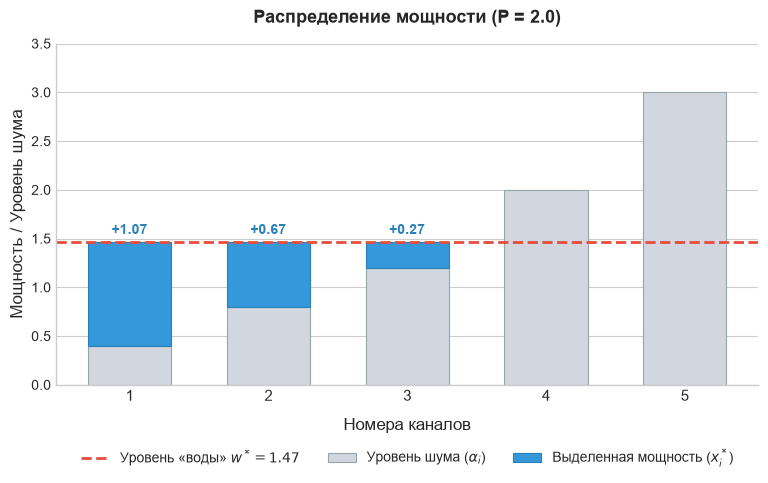

In [9]:
from scipy.optimize import brentq

n = len(alpha)

def phi(w):
    return np.sum(np.maximum(0, w - alpha)) - P

w_star = brentq(phi, alpha.min(), alpha.min() + P + alpha.max())
x_star = np.maximum(0, w_star - alpha)
print(f"w* = {w_star:.6f}")
print(f"x* = {x_star}")
print(f"sum(x*) = {x_star.sum():.6f}")

lam = -1 / w_star
mu = np.where(x_star > 1e-9, 0.0, 1/w_star - 1/alpha)
print(f"λ* = {lam:.6f},  μ* = {mu}")

def f(x): return -np.sum(np.log(alpha + x))
def eq(x): return x.sum() - P

res = minimize(f, np.full(n, P/n), method='SLSQP',
               bounds=[(0, None)]*n, constraints={'type': 'eq', 'fun': eq})
print(f"\nSLSQP: f* = {res.fun:.6f}, x = {res.x}")

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 5))

indices = np.arange(n)

ax.bar(indices, alpha, color='#D2D7DF', edgecolor='#95A5A6', linewidth=0.8, 
       label='Уровень шума ($\\alpha_i$)', width=0.6)
water_mask = x_star > 1e-6
ax.bar(indices[water_mask], x_star[water_mask], bottom=alpha[water_mask], 
       color='#3498DB', edgecolor='#2980B9', linewidth=0.8, 
       label='Выделенная мощность ($x_i^*$)', width=0.6)
ax.axhline(w_star, color='#E74C3C', linestyle='--', linewidth=2, 
           label=f'Уровень «воды» $w^* = {w_star:.2f}$')

for i in range(n):
    total_height = alpha[i] + x_star[i]
    if x_star[i] > 0.01:
        ax.text(i, total_height + 0.05, f'+{x_star[i]:.2f}', 
                ha='center', va='bottom', color='#2980B9', fontsize=10, fontweight='bold')

ax.set_xticks(indices)
ax.set_xticklabels([f'{i+1}' for i in indices], fontsize=11)
ax.set_xlabel('Номера каналов', fontsize=12, labelpad=10)
ax.set_ylabel('Мощность / Уровень шума', fontsize=12)
ax.set_ylim(0, max(w_star, alpha.max()) + 0.5)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=10, frameon=False)
ax.set_title(f'Распределение мощности (P = {P})', 
             fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

In [11]:
eps = 1e-5
def solve(P_val):
    w = brentq(lambda w: np.sum(np.maximum(0, w - alpha)) - P_val,
               alpha.min(), alpha.min() + P_val + alpha.max())
    return np.sum(np.log(alpha + np.maximum(0, w - alpha)))

C0 = solve(P)
C1 = solve(P + eps)
print(f"Конечная разность: (C(P+eps) - C(P))/eps = {(C1 - C0)/eps:.6f}")
print(f"Теория: 1/w* = {1/w_star:.6f}")

Конечная разность: (C(P+eps) - C(P))/eps = 0.681817
Теория: 1/w* = 0.681818


## Бонус ★★★ (+1 балл). Максимум энтропии

Система может находиться в состояниях $i = 1, \dots, n$ с энергиями $E_i$. Какое распределение вероятностей $p$ наиболее «неопределённо» при известной средней энергии $\bar E$? Задача:
$$\max_p\ H(p) = -\sum_i p_i \log p_i \quad\text{при}\quad \sum_i p_i = 1,\ \ \sum_i p_i E_i = \bar E,\ \ p_i \ge 0$$
(с соглашением $0 \log 0 = 0$).

1. Докажите, что задача выпукла (в форме $\min -H$).
2. Без ограничения на энергию найдите решение через множитель Лагранжа.
3. С ограничением на энергию выпишите условия ККТ и покажите, что $p_i^\ast = e^{-\beta E_i} / Z$, $Z = \sum_j e^{-\beta E_j}$ (распределение Больцмана). Почему ограничения $p_i \ge 0$ оказываются неактивными? Как связан $\beta$ с множителями?
4. Для $E = (0, 1, 2, 3)$ и $\bar E = 1$ найдите $\beta$ численно (одно уравнение на одно число, `scipy.optimize.brentq`) и $p^\ast$. Почему $\beta > 0$? Проверьте конечной разностью, что $dH^\ast/d\bar E = \beta$ — это определение температуры из термодинамики, $\beta = 1/T$.

**Ответ:**

1. Приведём задачу к форме минимума: $\min_p f(p) = \sum_{i=1}^n p_i \log p_i$ при $\sum_{i=1}^n p_i = 1$, $\sum_{i=1}^n p_i E_i = \bar{E}$, $p_i \ge 0$  
Функция $g(t) = t \log t$ при $t > 0$ имеет вторую производную $g''(t) = 1/t > 0$, значит строго выпукла. Целевая функция $f(p) = \sum_{i=1}^n g(p_i)$ является суммой выпуклых функций, следовательно, выпукла  
Ограничения: $\sum p_i = 1$ и $\sum p_i E_i = \bar{E}$ - аффинные равенства; $p_i \ge 0$ - аффинное неравенство. Цель выпукла, равенства аффинны, неравенства с вогнутыми функциями $\Rightarrow$ задача выпукла  

2. Решение без ограничения на энергию. Задача: $\max H(p)$ при $\sum p_i = 1$, $p_i \ge 0$  
Лагранжиан: $L(p, \lambda, \mu) = -\sum_{i=1}^n p_i \log p_i - \lambda\!\left(\sum_{i=1}^n p_i - 1\right) - \sum_{i=1}^n \mu_i p_i$  
Система ККТ:
1) $\frac{\partial L}{\partial p_i} = -\log p_i - 1 - \lambda - \mu_i = 0$ для каждого $i$
2) Допустимость: $\sum p_i = 1$, $p_i \ge 0$
3) Знаки: $\mu_i \ge 0$
4) Комплементарная нежёсткость: $\mu_i p_i = 0$

Предположим, что все $p_i > 0$. Тогда $\mu_i = 0$ для всех $i$. Из условия 1: $-\log p_i - 1 - \lambda = 0 \implies p_i = e^{-1-\lambda}$  
Все $p_i$ равны между собой. Из ограничения $\sum p_i = 1$: $n \cdot e^{-1-\lambda} = 1 \implies e^{-1-\lambda} = 1/n$  
Решением является $p_i^* = 1/n$ - равномерное распределение. Максимальная энтропия $H^* = \log n$

3. Лагранжиан:
$L(p, \lambda, \nu, \mu) = -\sum_{i=1}^n p_i \log p_i - \lambda\!\left(\sum_{i=1}^n p_i - 1\right) - \nu\!\left(\sum_{i=1}^n p_i E_i - \bar{E}\right) - \sum_{i=1}^n \mu_i p_i$  
Система ККТ:
1) $\frac{\partial L}{\partial p_i} = -\log p_i - 1 - \lambda - \nu E_i - \mu_i = 0$
2) $\sum p_i = 1$, $\sum p_i E_i = \bar{E}$, $p_i \ge 0$
3) $\mu_i \ge 0$
4) $\mu_i p_i = 0$  

Предположим, что все $p_i > 0$. Тогда $\mu_i = 0$, и из условия 1: $\log p_i = -1 - \lambda - \nu E_i \implies p_i = e^{-1-\lambda} \cdot e^{-\nu E_i}$  
Обозначим $\beta = \nu$ и $Z = e^{1+\lambda}$. Тогда $p_i = e^{-\beta E_i}/Z$. Из условия $\sum p_i = 1$: $Z = \sum_{j=1}^n e^{-\beta E_j}$  
Параметр $\beta$ определяется из ограничения на среднюю энергию: $\frac{\sum_{i=1}^n E_i e^{-\beta E_i}}{\sum_{j=1}^n e^{-\beta E_j}} = \bar{E}$  
Ограничения $p_i \ge 0$ неактивны, поскольку $e^{-\beta E_i} > 0$ для любого конечного $\beta$ и $E_i$, и $Z > 0$, то $p_i^* = e^{-\beta E_i}/Z > 0$ строго. Значит, ограничения $p_i \ge 0$ неактивны, и $\mu_i = 0$  
$\beta = \nu$ множитель Лагранжа при ограничении на среднюю энергию $\sum p_i E_i = \bar{E}$  

4. $E = (0, 1, 2, 3)$ и $\bar{E} = 1$  
Обозначим $q = e^{-\beta}$. Уравнение на среднюю энергию: $\frac{q + 2q^2 + 3q^3}{1 + q + q^2 + q^3} = 1 \implies 2q^3 + q^2 - 1 = 0$
$q = \frac{1}{6} \big ( \sqrt[3]{53 + 6\sqrt{78}} + \sqrt[3]{53 - 6\sqrt{78}} - 1\big ) \approx 0,6573$, откуда $\beta = -\log q \approx 0,4196$  
Средняя энергия равномерного распределения равна $(0+1+2+3)/4 = 1.5$. Поскольку требуемая $\bar{E} = 1 < 1.5$, нужно сдвинуть распределение в сторону состояний с меньшей энергией.  
При $\beta > 0$ состояния с меньшим $E_i$ получают больший вес $e^{-\beta E_i}$, что и снижает среднюю энергию  
$p^* \approx (0,4214,\ 0,2770,\ 0,1820,\ 0,1197)$  
Проверка $dH^*/d\bar{E} = \beta$ конечной разностью в коде ниже

In [14]:
E = np.array([0, 1, 2, 3])

def solve_boltzmann(E_bar):
    def eq(beta):
        exp_b = np.exp(-beta * E)
        Z = np.sum(exp_b)
        p = exp_b / Z
        return np.sum(p * E) - E_bar
    beta = brentq(eq, 0.01, 10.0)
    exp_b = np.exp(-beta * E)
    Z = np.sum(exp_b)
    p = exp_b / Z
    H = -np.sum(p * np.log(p + 1e-15))
    return beta, p, H

E_bar = 1.0
beta_star, p_star, H0 = solve_boltzmann(E_bar)
print(f"B* = {beta_star:.6f}")
print(f"p* = {p_star}")
print(f"H* = {H0:.6f}")

eps = 1e-5
_, _, H1 = solve_boltzmann(E_bar + eps)
print(f"\nКонечная разность dH*/dE_bar = {(H1 - H0)/eps:.6f}")
print(f"B* = {beta_star:.6f}")

B* = 0.419618
p* = [0.42135095 0.27695318 0.1820408  0.11965507]
H* = 1.283907

Конечная разность dH*/dE_bar = 0.419613
B* = 0.419618


---

Перед сдачей: `Kernel → Restart Kernel and Run All Cells`, убедитесь, что ни одна ячейка не падает и все ответы заполнены. Файл — `submissions/hw02/<фамилия>.ipynb`, дальше по [инструкции](../CONTRIBUTING.md).